# Reprocess the label-free proteomics data
Join the FDL proteomics data (tumour tissues only) with the ProCan cell line data. Given they had already used DIA-NN normalization and maxLFQ, further normalization is not necessary. Missing values are pre-imputed to 0

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy import sparse
import scib

from scipy.optimize import least_squares
from scipy.special import ndtr

In [ ]:
import yaml
with open("../config/config.local.yaml", "r") as f:
    config = yaml.safe_load(f)
basedir = config['code_dir']

data_input_dir = os.path.join(config["output_data_dir"], "processed_proteomics_data")  # where the cell line and tumor proteomics data in h5ad format were saved

data_output_dir = os.path.join(config["output_data_dir"], "processed_proteomics_data")

In [ ]:
from proteome_anndata_plot import boxplot_sample_intensities
# manual mapping of the tissue and cancer (sub)type
manual_mapping = pd.read_csv(os.path.join(basedir, "00_manual_mapping", "FDL_ProCan", "data_source_tissue_cancer_manual_annotation.csv"))
sys.path.insert(0, os.path.join(basedir, "03_analysisScripts"))
from Utils.helper_functions import add_joint_annotations
from Utils.color_palette import palette_data_source_label_free, tissue_palette

In [4]:
palette_data_source_label_free

{'FDL_patient': '#1f77b4', 'ProCan_cell_line': '#ff7f0e'}

## FDL data
Note: fitler the patient data here for tumor samples only.

In [ ]:
# Import the FDL data
fn = "PanCancer_Cai2025_FDL.h5ad"
adata = sc.read_h5ad(os.path.join(data_input_dir, fn))
adata.obs

,index,Cancer type,Tissue type,Cancer subtype
SampleID,,,,
00J63,00J63,Normal,Adipose tissue,Normal_adipose_tissue
00J5Z,00J5Z,Normal,Adipose tissue,Normal_adipose_tissue
00G65,00G65,Normal,Adipose tissue,Normal_adipose_tissue
00G5X,00G5X,Normal,Adipose tissue,Normal_adipose_tissue
00G6X,00G6X,Normal,Adipose tissue,Normal_adipose_tissue
...,...,...,...,...
000D0,000D0,Normal,Uterus,Normal_uterus
000CO,000CO,Normal,Uterus,Normal_uterus
000DG,000DG,Normal,Uterus,Normal_uterus


In [6]:
adata.X

array([[       nan,        nan, 5.26245333, ...,        nan, 6.14554469,
        7.88344337],
       [       nan, 4.96555723, 6.17242708, ...,        nan, 5.7706168 ,
        8.97341375],
       [       nan,        nan, 5.2512171 , ...,        nan, 4.46755626,
        7.85466105],
       ...,
       [       nan,        nan, 3.43889386, ...,        nan, 6.97889213,
        6.63094359],
       [       nan,        nan, 3.22076059, ...,        nan, 7.51457102,
        6.58147889],
       [       nan,        nan, 3.93886096, ...,        nan, 7.08609559,
        6.7105287 ]])

In [7]:
# Remove the tumor-free samples
adata = adata[adata.obs["Cancer type"] != "Normal"]
# remove the proteins with all missing values
adata = adata[:, ~np.isnan(adata.X).all(axis=0)].copy()
# add the manual annotations
adata

AnnData object with n_obs × n_vars = 766 × 9062
    obs: 'index', 'Cancer type', 'Tissue type', 'Cancer subtype'
    uns: 'Tissue type_colors', 'intensity_threshold', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'missing_rate_sample', 'number_detection_sample'
    varm: 'PCs', 'median_intensity', 'missing_rate_gene', 'sum_intensity'
    layers: 'median_norm', 'msBayesImpute', 'threshold_controlled'
    obsp: 'connectivities', 'distances'

/local-conda-envs/tacongqu/protint/lib/python3.11/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


<Axes: title={'center': 'Boxplot of intensities per sample (layer: None)'}, xlabel='Samples', ylabel='Intensity'>

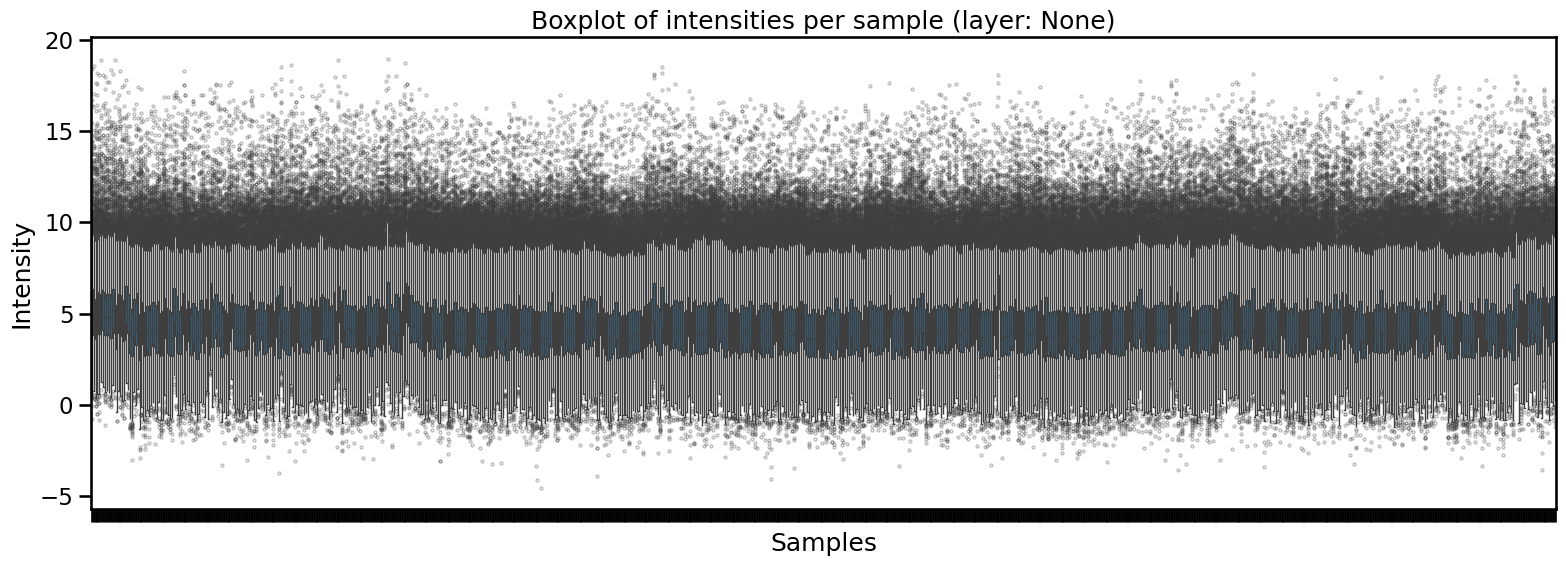

In [8]:
# plot the original intensity
boxplot_sample_intensities(adata)

In [9]:
def _get_dense_X(adata):
    import numpy as np
    from scipy import sparse

    X = adata.X
    if sparse.issparse(X):
        X = X.toarray()
    else:
        X = np.asarray(X)
    return X


def plot_missingness_vs_abundance(adata):
    import numpy as np

    X = _get_dense_X(adata)

    # Per-protein missingness and median abundance
    missing_pct = np.isnan(X).mean(axis=0) * 100
    median_abundance = np.nanmedian(X, axis=0)

    # Store in adata.var
    adata.var["missing_pct"] = missing_pct
    adata.var["median_abundance"] = median_abundance

    # All detected values only
    detected_mask = ~np.isnan(X)
    row_idx, col_idx = np.where(detected_mask)
    all_detected_abundance = X[row_idx, col_idx]
    missing_for_each_detected_value = missing_pct[col_idx]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # 1) Median protein abundance vs missingness
    axes[0].scatter(median_abundance, missing_pct, alpha=0.7, s=20)
    axes[0].set_xlabel("log2 Median protein abundance")
    axes[0].set_ylabel("Missing values (%)")
    axes[0].set_title("Median abundance vs missingness")

    # 2) All detected abundances vs protein missingness
    # hexbin is usually better than scatter here because there can be many points
    hb = axes[1].hexbin(
        all_detected_abundance,
        missing_for_each_detected_value,
        gridsize=50,
        mincnt=1
    )
    axes[1].set_xlabel("Log2 Detected protein abundance (all values)")
    axes[1].set_ylabel("Missing values (%)")
    axes[1].set_title("All detected abundances vs protein missingness")
    fig.colorbar(hb, ax=axes[1], label="Count")

    plt.tight_layout()
    plt.show()

def plot_global_detected_distribution(adata):
    import numpy as np
    from scipy import stats

    X = _get_dense_X(adata)
    detected_global = X[~np.isnan(X)]

    if detected_global.size == 0:
        raise ValueError("No detected values found in adata.X")

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # 1) Global distribution
    sns.histplot(detected_global, bins=50, kde=True, ax=axes[0])
    axes[0].set_xlabel("Log2 Detected protein abundance")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Global distribution of detected values")

    # 2) Global Q-Q plot
    std = np.std(detected_global)
    if std == 0:
        axes[1].text(
            0.5, 0.5,
            "Q-Q plot unavailable\n(all detected values are identical)",
            ha="center", va="center"
        )
        axes[1].set_axis_off()
    else:
        z = (detected_global - np.mean(detected_global)) / std
        stats.probplot(z, dist="norm", plot=axes[1])
        axes[1].set_title("Global Q-Q plot vs Gaussian")

    plt.tight_layout()
    plt.show()

def plot_per_protein_distributions_by_missingness(
    adata,
    bins=(0, 25, 50, 75, 100),
    n_per_bin=4,
    min_detected=20,
    random_state=0
):
    import numpy as np

    X = _get_dense_X(adata)

    missing_pct = np.isnan(X).mean(axis=0) * 100
    n_detected = np.sum(~np.isnan(X), axis=0)

    rng = np.random.default_rng(random_state)
    n_rows = len(bins) - 1
    n_cols = n_per_bin

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4 * n_cols, 3 * n_rows),
        squeeze=False
    )

    for i, (low, high) in enumerate(zip(bins[:-1], bins[1:])):
        if i < n_rows - 1:
            in_bin = np.where(
                (missing_pct >= low) &
                (missing_pct < high) &
                (n_detected >= min_detected)
            )[0]
        else:
            in_bin = np.where(
                (missing_pct >= low) &
                (missing_pct <= high) &
                (n_detected >= min_detected)
            )[0]

        if len(in_bin) == 0:
            for j in range(n_cols):
                axes[i, j].text(
                    0.5, 0.5,
                    f"No proteins in {low}-{high}%",
                    ha="center", va="center"
                )
                axes[i, j].set_axis_off()
            continue

        chosen = rng.choice(in_bin, size=min(n_cols, len(in_bin)), replace=False)

        for j in range(n_cols):
            ax = axes[i, j]

            if j >= len(chosen):
                ax.set_axis_off()
                continue

            protein_idx = chosen[j]
            vals = X[:, protein_idx]
            vals = vals[~np.isnan(vals)]

            sns.histplot(vals, bins=30, kde=True, ax=ax)

            protein_name = (
                str(adata.var_names[protein_idx])
                if hasattr(adata, "var_names")
                else f"Protein {protein_idx}"
            )

            ax.set_title(
                f"{protein_name}\nmissing={missing_pct[protein_idx]:.1f}%"
            )
            ax.set_xlabel("Log2 protein Abundance")
            ax.set_ylabel("Count")

    plt.tight_layout()
    plt.show()

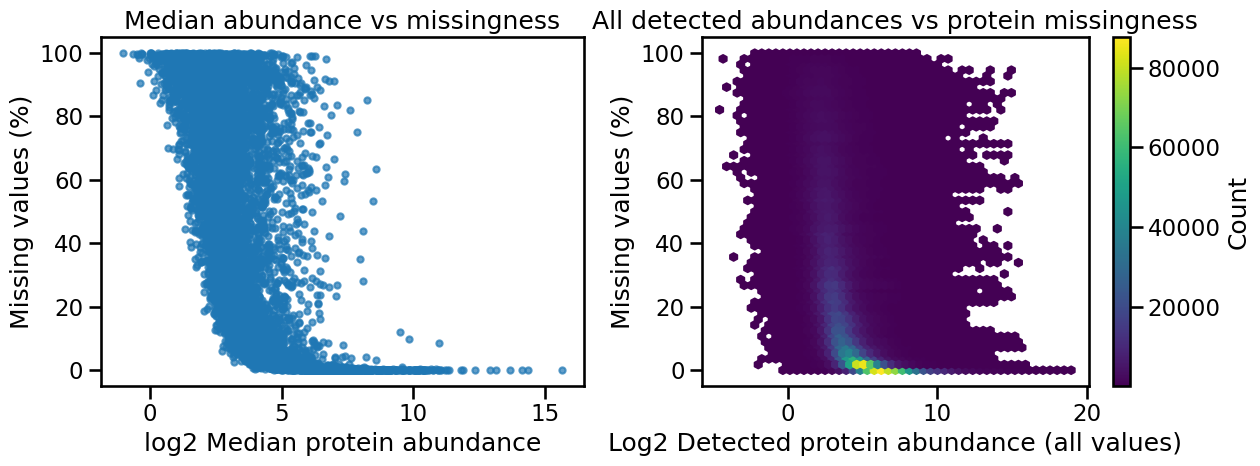

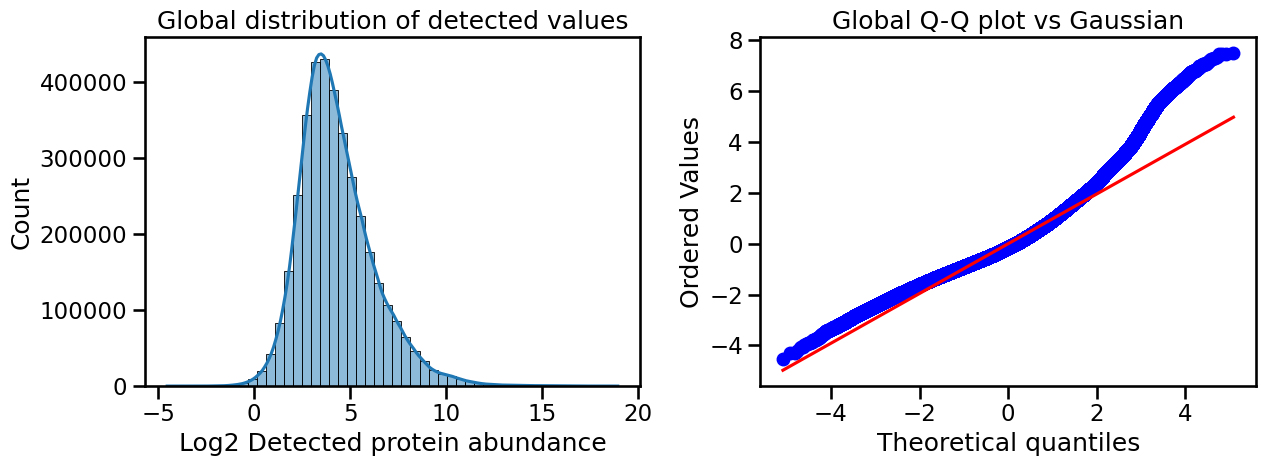

In [10]:
plot_missingness_vs_abundance(adata)
plot_global_detected_distribution(adata)

In [11]:
adata_FDL = adata.copy()

## ProCan cell lines data

In [ ]:
# Import the ProCan data
fn = "PanCancer_Goncalves2022_cancer_cell_lines.h5ad"
adata = sc.read_h5ad(os.path.join(data_input_dir, fn))
adata

AnnData object with n_obs × n_vars = 949 × 6692
    obs: 'index', 'Project_Identifier', 'Source', 'Identifier', 'Gender', 'Tissue_type', 'Cancer_type', 'Cancer_subtype', 'Haem_lineage', 'BROAD_ID', 'CCLE_ID', 'ploidy', 'mutational_burden', 'msi_status', 'growth_properties', 'growth', 'size', 'media', 'replicates_correlation', 'number_of_proteins', 'EMT', 'Proteasome', 'TranslationInitiation', 'CopyNumberInstability', 'GeneExpressionCorrelation', 'CopyNumberAttenuation', 'F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15'
    var: 'UniprotID', 'organism'
    uns: 'Tissue_type_colors', 'intensity_threshold', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'missing_rate_sample', 'number_detection_sample'
    varm: 'PCs', 'median_intensity', 'missing_rate_gene', 'sum_intensity'
    layers: 'median_norm', 'msBayesImpute', 'threshold_controlled'
    obsp: 'connectivities', 'distances'

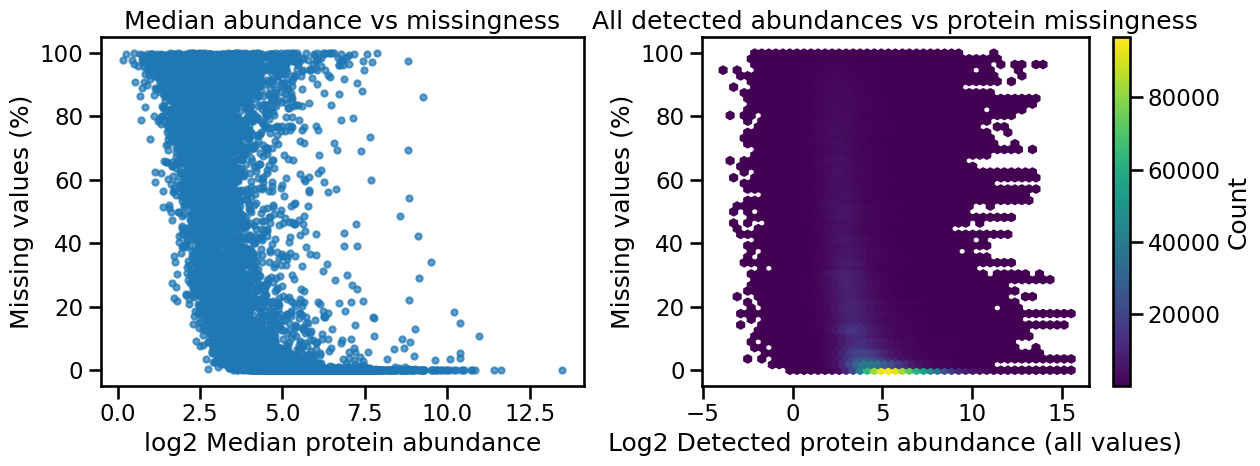

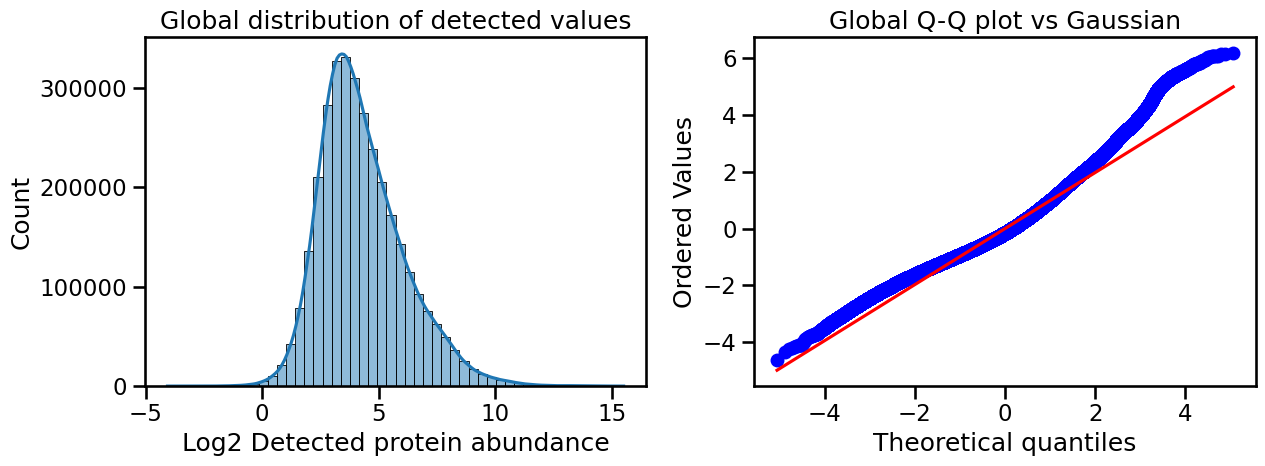

In [13]:
plot_missingness_vs_abundance(adata)
plot_global_detected_distribution(adata)

In [14]:
adata_Procan = adata.copy()

## Join two datasets

In [15]:
adata_Procan.obs["data_source"] = "ProCan_cell_line"
adata_FDL.obs["data_source"] = "FDL_patient"
adata_Procan.obs.rename(columns={"Cancer_type": "Cancer type", 
                                 "Cancer_subtype": "Cancer subtype",
                                 "Tissue_type": "Tissue type"}, inplace=True)
adata_FDL.obs["Cancer subtype"] = [s.replace("_", " ") for s in adata_FDL.obs["Cancer subtype"]]
adata_Procan.var_names = adata_Procan.var["UniprotID"]
adata_Procan.obs

,index,Project_Identifier,Source,Identifier,Gender,Tissue type,Cancer type,Cancer subtype,Haem_lineage,BROAD_ID,...,F7,F8,F9,F10,F11,F12,F13,F14,F15,data_source
Cell_line,,,,,,,,,,,,,,,,,,,,,
BC-1,BC-1,SIDM00896;BC-1,ATCC,CVCL_1079,Male,Haematopoietic and Lymphoid,B-Cell Non-Hodgkin's Lymphoma,Primary effusion lymphoma,B lymphoid,ACH-002214,...,0.769344541,1.655735696,2.109066796,-0.056366659,-0.550704882,0.22918636,0.48678876,0.299904549,-0.319624837,ProCan_cell_line
L-363,L-363,SIDM00312;L-363,DSMZ,CVCL_1357,Female,Haematopoietic and Lymphoid,Plasma Cell Myeloma,NaN,B lymphoid,ACH-000183,...,1.267371741,3.302839254,1.927399012,1.67645876,-1.009455463,-0.329970134,0.530467659,0.585515536,-0.092114513,ProCan_cell_line
EoL-1-cell,EoL-1-cell,SIDM00277;EoL-1-cell,RIKEN,CVCL_0258,Male,Haematopoietic and Lymphoid,Acute Myeloid Leukemia,Chronic Eosinophilic Leukemia,Myeloid,ACH-000198,...,-3.082193494,-1.778517568,0.218588171,-0.191836004,-1.5289751,0.444940467,-0.23824369,1.183521049,-0.245174026,ProCan_cell_line
NCI-H727,NCI-H727,SIDM01119;NCI-H727,ATCC,CVCL_1584,Female,Lung,Carcinoid Tumour,Lung Carcinoid Tumor,NaN,ACH-000775,...,1.266913309,-0.128102385,0.1088428,-0.895634273,-0.813593711,0.352701873,-1.68028983,0.4363571,-0.034756331,ProCan_cell_line
MV-4-11,MV-4-11,SIDM00657;MV-4-11,ATCC,CVCL_0064,Male,Haematopoietic and Lymphoid,Acute Myeloid Leukemia,Acute Monocytic leukemia,Myeloid,ACH-000045,...,-2.825198424,-2.446800068,0.334810381,-2.487931171,-1.485627055,0.177513259,-0.218151504,0.501118696,-0.044598198,ProCan_cell_line
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NCI-H1304,NCI-H1304,SIDM00648;NCI-H1304,ATCC,CVCL_1462,Female,Lung,Small Cell Lung Carcinoma,NaN,NaN,ACH-002169,...,1.449034752,0.31146681,0.11554397,-1.726695985,-2.058036236,0.032151033,0.393321395,2.092905586,0.334610831,ProCan_cell_line
SC-1,SC-1,SIDM00400;SC-1,DSMZ,CVCL_1888,Male,Haematopoietic and Lymphoid,B-Cell Non-Hodgkin's Lymphoma,Follicular lymphoma,B lymphoid,ACH-002392;ACH-002303,...,1.425412366,-1.112903023,0.338355929,1.770651317,1.887564896,-0.350324005,0.333861278,-2.337964888,0.059720513,ProCan_cell_line
SCC-25,SCC-25,SIDM01082;SCC-25,ATCC,CVCL_1682,Male,Head and Neck,Head and Neck Carcinoma,Tongue Squamous Cell Carcinoma,NaN,ACH-000188,...,0.750212072,1.718657183,-1.036830459,0.345811292,0.471746302,0.497632479,2.457353973,1.158981344,0.01817463,ProCan_cell_line


In [16]:
# --- 1) Align features (use only genes/features present in BOTH datasets) ---
common_vars = adata_Procan.var_names[adata_Procan.var_names.isin(adata_FDL.var_names)]

# --- 2) Ensure required obs columns exist and normalize requested columns ---
required_cols = ["index", "Cancer type", "Cancer subtype", "Tissue type", "data_source"]

def to_lower_and_fill_categorical(s: pd.Series) -> pd.Series:
    s_str = s.astype("string")
    s_str = s_str.str.lower()
    s_str = s_str.fillna("missing")
    return pd.Series(pd.Categorical(s_str), index=s.index, name=s.name)

def prepare_obs(A: ad.AnnData, default_source: str) -> None:
    if "index" not in A.obs:
        A.obs["index"] = A.obs_names

    if "data_source" not in A.obs:
        A.obs["data_source"] = default_source

    for col in ["Cancer type", "Cancer subtype", "Tissue type"]:
        if col in A.obs:
            A.obs[col] = to_lower_and_fill_categorical(A.obs[col])
        else:
            A.obs[col] = pd.Series(pd.Categorical(["missing"] * A.n_obs), index=A.obs.index)

    for col in required_cols:
        if col not in A.obs:
            A.obs[col] = (
                pd.Series(pd.Categorical(["missing"] * A.n_obs), index=A.obs.index)
                if col in ["Cancer type", "Cancer subtype", "Tissue type"]
                else "missing"
            )
    A.obs = A.obs[required_cols]

# --- helper: strip sidecars (avoids concat alignment headaches) ---
def strip_sidecars(A: ad.AnnData) -> ad.AnnData:
    for mapping in (A.obsm, A.varm, A.obsp, A.varp):
        for k in list(mapping.keys()):
            del mapping[k]
    return A

# --- helper: build merged object from a specific layer placed into .X ---
def merge_adata(name_procan="procan", name_fdl="fdl") -> ad.AnnData:
    # subset & copy
    ap = adata_Procan[:, common_vars].copy()
    af = adata_FDL[:, common_vars].copy()

    # standardize obs
    prepare_obs(ap, default_source=name_procan)
    prepare_obs(af, default_source=name_fdl)

    # strip sidecars
    strip_sidecars(ap)
    strip_sidecars(af)

    # concat
    merged = ad.concat([ap, af], axis=0, join="inner", merge="first")
    return merged

# --- 3) Build the two merged objects you want ---
adata_merged = merge_adata(name_procan="procan", name_fdl="fdl")
adata_merged.layers["detected"] = ~np.isnan(adata_merged.X)
adata_merged.X = np.nan_to_num(adata_merged.X, nan=0)
# remove unnecessary layers if they exist
for layer in ["msBayesImpute", "median_norm", "threshold_controlled"]:
    if layer in adata_merged.layers:
        del adata_merged.layers[layer]

adata_merged = add_joint_annotations(adata_merged, manual_mapping)
adata_merged

AnnData object with n_obs × n_vars = 1715 × 6264
    obs: 'index', 'Cancer type', 'Cancer subtype', 'Tissue type', 'data_source', 'joint tissue type', 'joint Cancer type', 'joint Cancer subtype', 'matching cancer type', 'matching cancer subtype'
    var: 'UniprotID', 'organism', 'missing_pct', 'median_abundance'
    layers: 'detected'

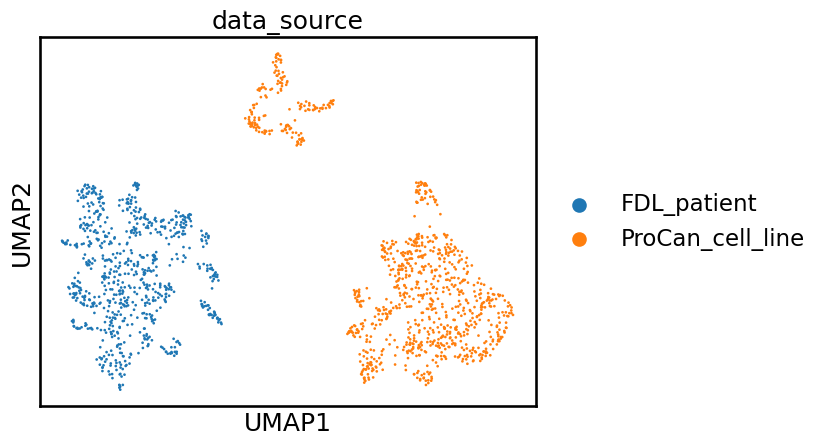

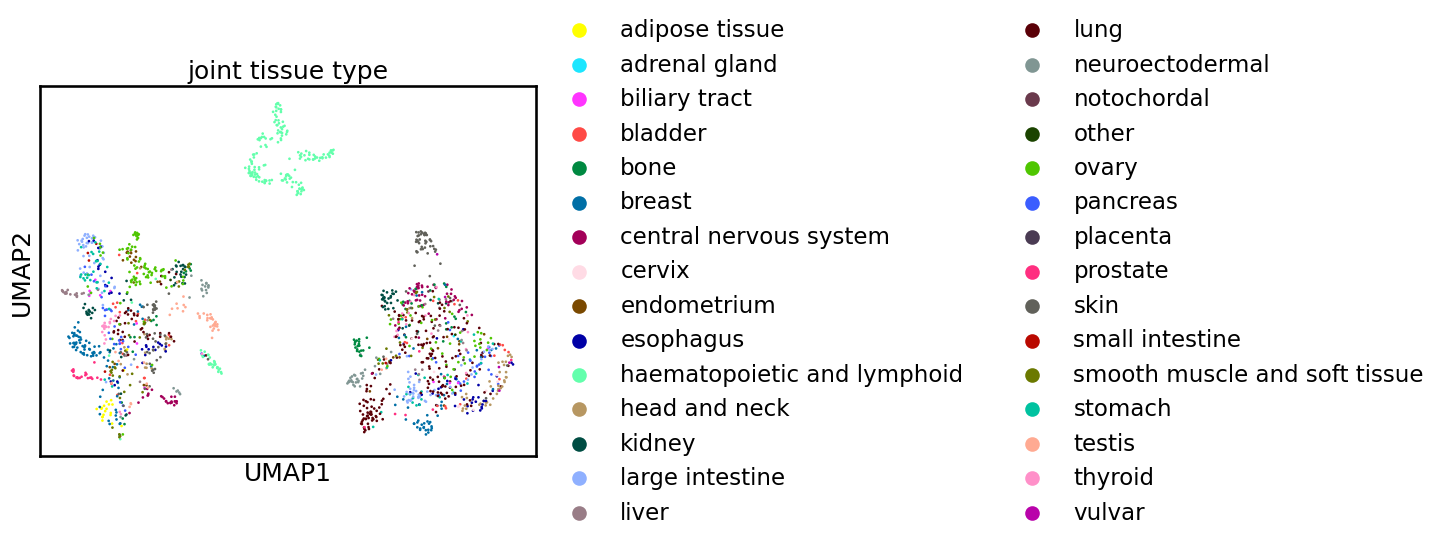

In [17]:
# quick umap of the adata
# Use the imputed layer as the working matrix
sc.pp.pca(adata_merged, n_comps=50, mask_var=None)

# Build neighbor graph from the PCA representation computed above
sc.pp.neighbors(adata_merged, n_neighbors=15, n_pcs=50, use_rep="X_pca")

# UMAP with your settings
sc.tl.umap(adata_merged, min_dist=0.5)

# (Optional) quick plot
sc.pl.umap(adata_merged, color="data_source", size=15)
sc.pl.umap(adata_merged, color="joint tissue type", size=15)

In [18]:
# save the merged object for later use
adata_merged.write_h5ad(os.path.join(data_output_dir, "1_1_9_ProCan_FDL_PanCancer_merged.h5ad"))

## Subset the data for min 20 samples per tissues

In [19]:
# Count samples per joint tissue type in each dataset
tissue_counts = (
    adata_merged.obs
    .groupby(["joint tissue type", "data_source"], observed=True)
    .size()
    .unstack(fill_value=0)
)

for src in ["ProCan_cell_line", "FDL_patient"]:
    if src not in tissue_counts.columns:
        tissue_counts[src] = 0

# Keep only tissues with at least 20 samples in BOTH datasets
keep_tissues = tissue_counts.index[
    (tissue_counts["ProCan_cell_line"] >= 20) &
    (tissue_counts["FDL_patient"] >= 20)
]

# Filter samples
adata_merged_tissue20 = adata_merged[
    adata_merged.obs["joint tissue type"].isin(keep_tissues)
].copy()

# Remove proteins/features undetected in all remaining samples
if "detected" not in adata_merged_tissue20.layers:
    raise KeyError("Expected adata_merged_tissue20.layers['detected'], but it was not found.")

detected = adata_merged_tissue20.layers["detected"]

# Works for both dense and sparse matrices
if hasattr(detected, "toarray"):
    keep_proteins = np.asarray(detected.sum(axis=0)).ravel() > 0
else:
    keep_proteins = detected.sum(axis=0) > 0

adata_merged_tissue20 = adata_merged_tissue20[:, keep_proteins].copy()

detected = adata_merged_tissue20.layers["detected"]

# Handle sparse or dense detected layer
if hasattr(detected, "toarray"):
    detected = detected.toarray()

detected = np.asarray(detected, dtype=bool)

batch_series = adata_merged_tissue20.obs["data_source"].astype(str)

keep_proteins = np.ones(adata_merged_tissue20.n_vars, dtype=bool)

for batch in ["ProCan_cell_line", "FDL_patient"]:
    batch_mask = batch_series.to_numpy() == batch

    detected_in_batch = detected[batch_mask].sum(axis=0) > 0
    keep_proteins &= detected_in_batch

    print(
        batch,
        "proteins detected at least once:",
        int(detected_in_batch.sum()),
        "/",
        adata_merged_tissue20.n_vars,
    )

adata_merged_tissue20 = adata_merged_tissue20[:, keep_proteins].copy()

print("Final proteins kept:", adata_merged_tissue20.n_vars)

adata_merged_tissue20

ProCan_cell_line proteins detected at least once: 6253 / 6263
FDL_patient proteins detected at least once: 6261 / 6263
Final proteins kept: 6251


AnnData object with n_obs × n_vars = 1321 × 6251
    obs: 'index', 'Cancer type', 'Cancer subtype', 'Tissue type', 'data_source', 'joint tissue type', 'joint Cancer type', 'joint Cancer subtype', 'matching cancer type', 'matching cancer subtype'
    var: 'UniprotID', 'organism', 'missing_pct', 'median_abundance'
    uns: 'pca', 'neighbors', 'umap', 'data_source_colors', 'joint tissue type_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'detected'
    obsp: 'distances', 'connectivities'

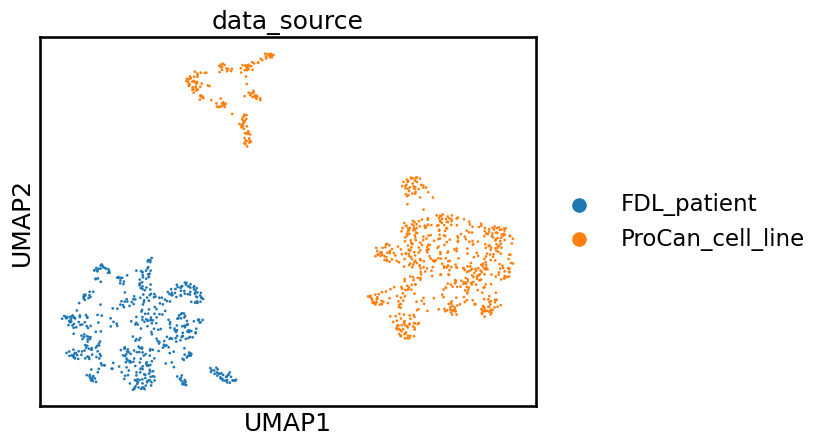

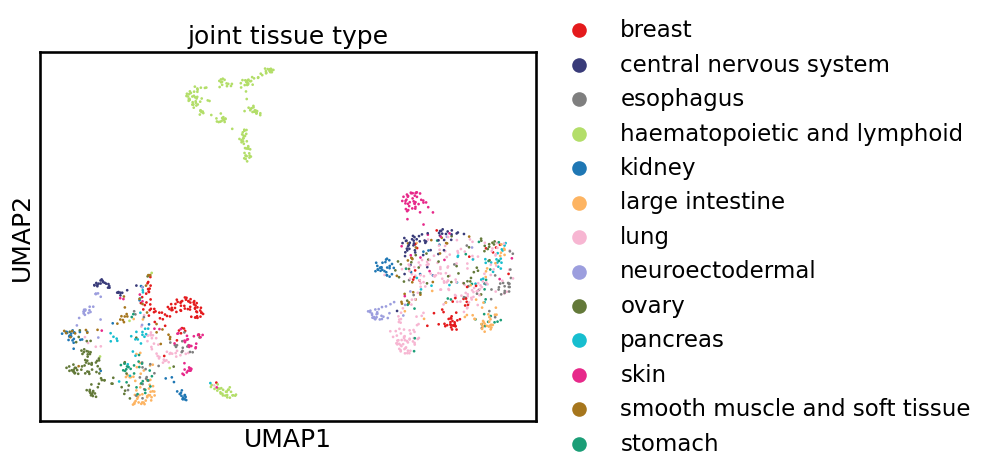

In [20]:
# quick umap of the adata
# Use the imputed layer as the working matrix
sc.pp.pca(adata_merged_tissue20, n_comps=50, mask_var=None)

# Build neighbor graph from the PCA representation computed above
sc.pp.neighbors(adata_merged_tissue20, n_neighbors=15, n_pcs=50, use_rep="X_pca")

# UMAP with your settings
sc.tl.umap(adata_merged_tissue20, min_dist=0.5)

# (Optional) quick plot
sc.pl.umap(adata_merged_tissue20, color="data_source", size=15)
sc.pl.umap(adata_merged_tissue20, color="joint tissue type", size=15, palette = tissue_palette)

In [32]:
adata_merged_tissue20.write_h5ad(os.path.join(data_output_dir, "1_1_9_ProCan_FDL_PanCancer_merged_tissue20.h5ad"))

## Fitting a probabilistic dropout curve to the data

In [22]:


def estimate_dropout_params_by_batch_direct(
    adata,
    batch_key="data_source",
    detected_layer="detected",
    batch_categories=None,
    robust_loss="soft_l1",
    f_scale=0.05,
):
    """
    Fit one batch-level dropout curve per batch directly in the original space:

        missing_rate(x) = 1 - Phi((x - rho) / zeta)

    where x is the per-protein median observed intensity.
    """

    def _to_dense_array(x, dtype=None):
        if hasattr(x, "toarray"):
            x = x.toarray()
        x = np.asarray(x)
        if dtype is not None:
            x = x.astype(dtype, copy=False)
        return x

    batch_series = adata.obs[batch_key].astype(str)

    if batch_categories is None:
        batch_categories = sorted(batch_series.unique())
    else:
        batch_categories = [str(x) for x in batch_categories]

    X = _to_dense_array(adata.X, dtype=np.float32)
    detected = _to_dense_array(adata.layers[detected_layer], dtype=np.bool_)
    feature_names = np.asarray(adata.var.index.astype(str))

    rho_by_batch = []
    zeta_by_batch = []
    batch_rows = []
    protein_rows = []

    for batch_name in batch_categories:
        batch_mask = batch_series.to_numpy() == batch_name
        X_b = X[batch_mask]
        M_b = detected[batch_mask]

        n_detected = M_b.sum(axis=0).astype(np.int32)

        obs_rate = M_b.mean(axis=0).astype(np.float64)
        miss_rate = 1.0 - obs_rate

        masked_x = np.where(M_b, X_b, np.nan)
        medians = np.nanmedian(masked_x, axis=0).astype(np.float64)

        x_fit = medians
        y_fit = miss_rate

        def p_miss(x, rho, zeta):
            return 1.0 - ndtr((x - rho) / zeta)

        def residuals(theta):
            rho_ = theta[0]
            zeta_ = np.exp(theta[1])
            y_hat = p_miss(x_fit, rho_, zeta_)
            return  y_fit - y_hat

        idx_mid = int(np.argmin(np.abs(y_fit - 0.5)))
        rho0 = float(x_fit[idx_mid])
        zeta0 = float(np.nanstd(x_fit))

        res = least_squares(
            residuals,
            x0=np.array([rho0, np.log(zeta0)], dtype=np.float64),
            method="trf",
            loss=robust_loss,
            f_scale=f_scale,
        )

        rho = float(res.x[0])
        zeta = float(np.exp(res.x[1]))

        rho_by_batch.append(rho)
        zeta_by_batch.append(zeta)

        batch_rows.append(
            {
                "batch": batch_name,
                "rho": rho,
                "zeta": zeta,
                "n_samples": int(batch_mask.sum()),
            }
        )

        protein_rows.extend(
            {
                "batch": batch_name,
                "protein": feature_names[j],
                "median_observed_intensity": float(medians[j]),
                "observed_rate": float(obs_rate[j]),
                "missing_rate": float(miss_rate[j]),
                "missing_pct": float(miss_rate[j] * 100.0),
                "n_detected_cells": int(n_detected[j]),
            }
            for j in range(len(feature_names))
        )

    return {
        "rho_by_batch": np.asarray(rho_by_batch, dtype=np.float32),
        "zeta_by_batch": np.asarray(zeta_by_batch, dtype=np.float32),
        "params_df": pd.DataFrame(batch_rows),
        "protein_stats_df": pd.DataFrame(protein_rows),
    }



def plot_median_missingness_by_data_source_directfit(dropout_fit, figsize_per_row=(10, 4), palette = None):
    protein_df = dropout_fit["protein_stats_df"].copy()
    params_df = dropout_fit["params_df"].copy()

    batches = params_df["batch"].tolist()
    n_batches = len(batches)

    # global x-axis limits across all batches
    global_xmin = protein_df["median_observed_intensity"].min()
    global_xmax = protein_df["median_observed_intensity"].max()

    fig, axes = plt.subplots(
        n_batches,
        1,
        figsize=(figsize_per_row[0], figsize_per_row[1] * n_batches),
        squeeze=False,
    )

    for i, batch_name in enumerate(batches):
        ax = axes[i, 0]

        df_b = protein_df[protein_df["batch"] == batch_name].copy()
        rho = float(params_df.loc[params_df["batch"] == batch_name, "rho"].iloc[0])
        zeta = float(params_df.loc[params_df["batch"] == batch_name, "zeta"].iloc[0])

        x = df_b["median_observed_intensity"].to_numpy(dtype=float)
        y = df_b["missing_pct"].to_numpy(dtype=float)
        
        if palette is not None:
            ax.scatter(x, y, alpha=0.5, s=20, c=palette[batch_name])
        else:
            ax.scatter(x, y, alpha=0.5, s=20)
        x_grid = np.linspace(x.min(), x.max(), 300)
        y_grid = (1.0 - ndtr((x_grid - rho) / zeta)) * 100.0

        ax.plot(
            x_grid,
            y_grid,
            color="red",
            linewidth=2.5,
            label=f"rho={rho:.2f}, zeta={zeta:.2f}",
        )
        
        ax.set_xlim(global_xmin, global_xmax)
        ax.set_xlabel("log2 Median protein abundance")
        ax.set_ylabel("Missing prob. (%)")
        ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0.0)

    plt.tight_layout()
    plt.show()

              batch       rho      zeta  n_samples
0       FDL_patient  2.552582  1.160423        766
1  ProCan_cell_line  3.112603  1.189726        949


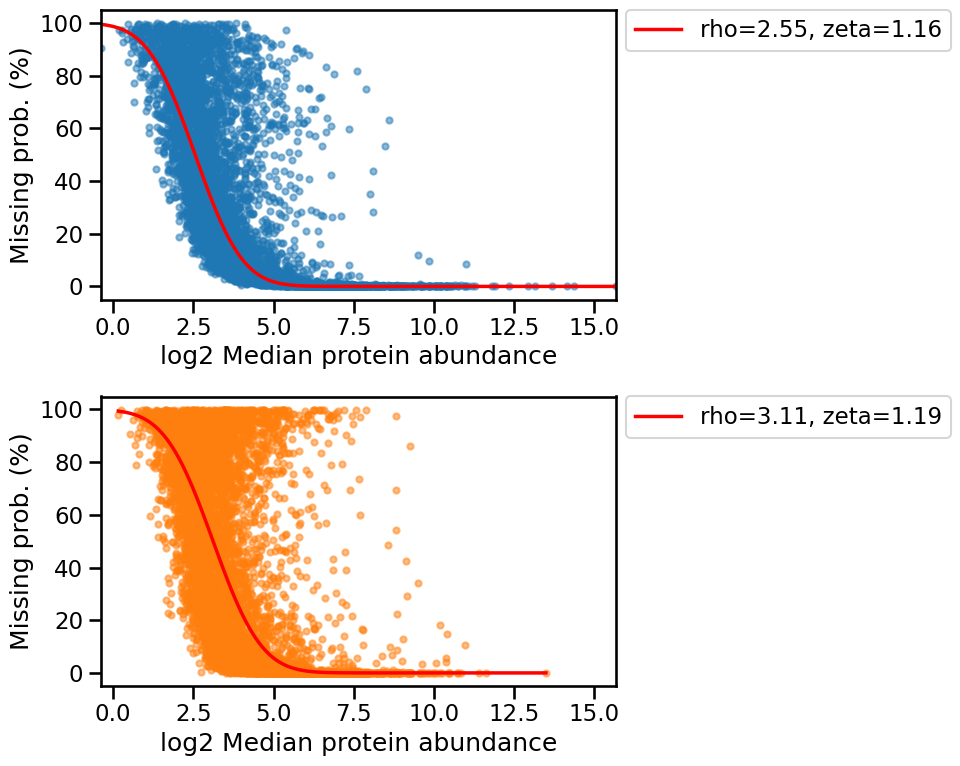

In [18]:
dropout_fit = estimate_dropout_params_by_batch_direct(
    adata_merged,
    batch_key="data_source",
    detected_layer="detected",
)

print(dropout_fit["params_df"])

plot_median_missingness_by_data_source_directfit(dropout_fit, palette=palette_data_source_label_free)

              batch       rho      zeta  n_samples
0       FDL_patient  2.507684  1.137001        550
1  ProCan_cell_line  3.099015  1.196542        771


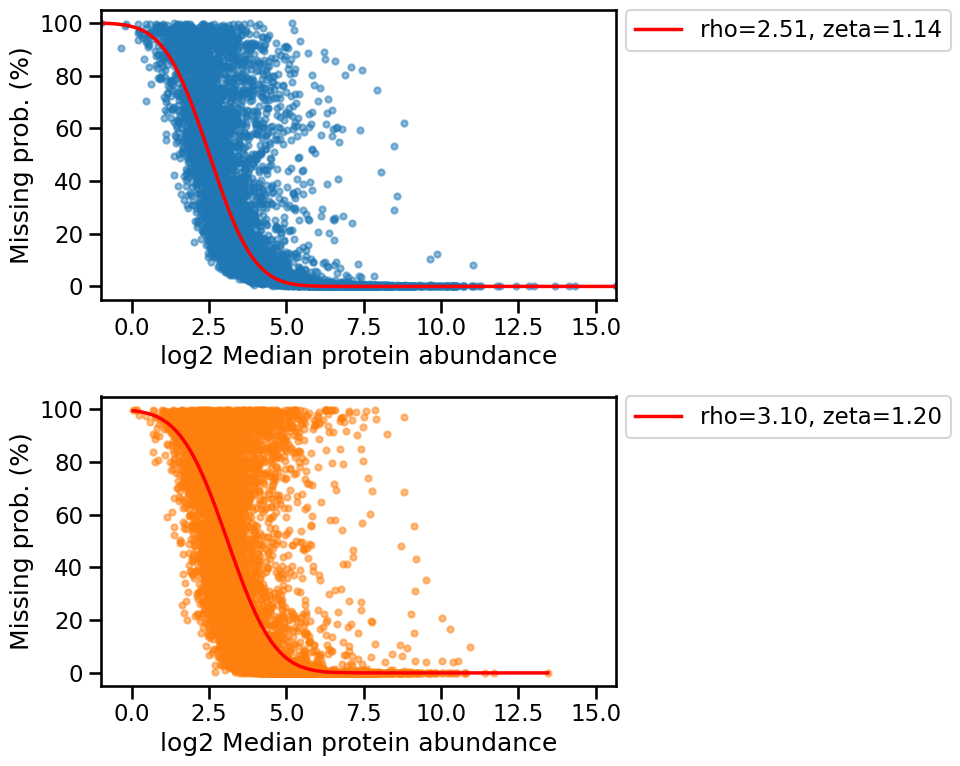

In [27]:
dropout_fit = estimate_dropout_params_by_batch_direct(
    adata_merged_tissue20,
    batch_key="data_source",
    detected_layer="detected",
)

print(dropout_fit["params_df"])

plot_median_missingness_by_data_source_directfit(dropout_fit, palette=palette_data_source_label_free)

## Compare pattern of missingness in the data

In [12]:
adata_merged

AnnData object with n_obs × n_vars = 1715 × 6264
    obs: 'index', 'Cancer type', 'Cancer subtype', 'Tissue type', 'data_source', 'joint tissue type', 'joint Cancer type', 'joint Cancer subtype', 'matching cancer type', 'matching cancer subtype'
    var: 'UniprotID', 'organism'
    layers: 'detected'

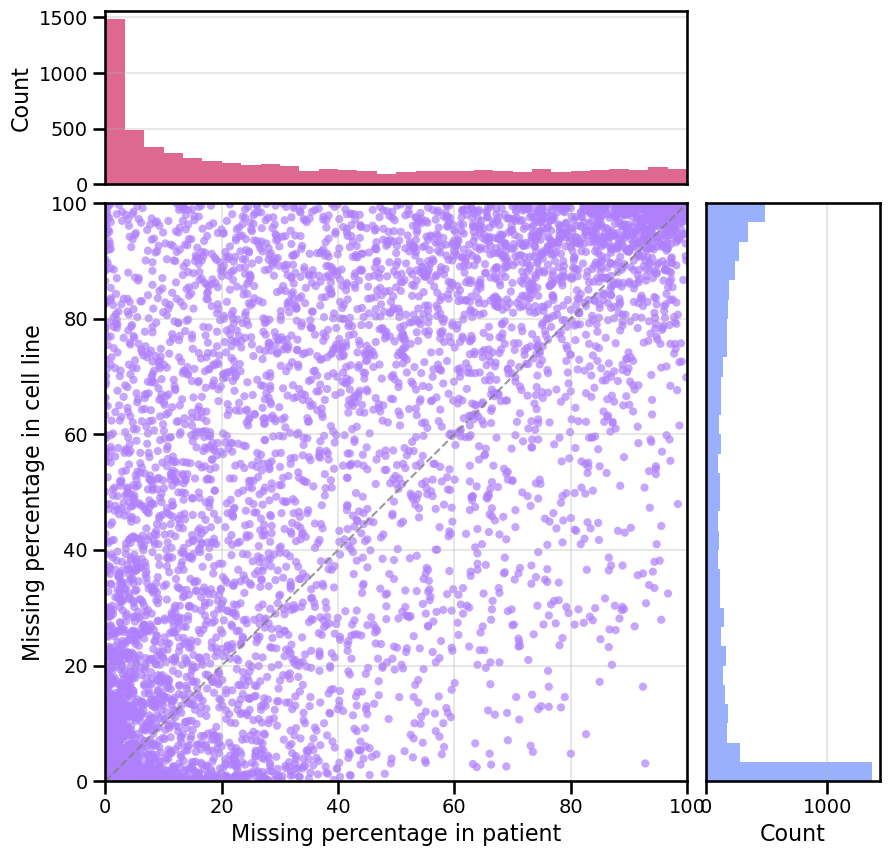

In [28]:
def plot_protein_missingness_joint(
    adata_merged,
    data_source_col="data_source",
    patient_label="FDL_patient",
    cellline_label="ProCan_cell_line",
    detected_layer="detected",
    return_df=False,
):
    plt.rcParams.update({
        "font.size": 15,
        "axes.titlesize": 18,
        "axes.labelsize": 16,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 15,
    })

    # Trix palette
    trix_palette = ["#58e3ff", "#87a2ff", "#af7ffc", "#da4e7d", "#f14848"]
    patient_color = trix_palette[3]
    cellline_color = trix_palette[1]
    scatter_color = trix_palette[2]

    is_patient = adata_merged.obs[data_source_col] == patient_label
    is_cellline = adata_merged.obs[data_source_col] == cellline_label

    detected = adata_merged.layers[detected_layer]

    if sparse.issparse(detected):
        det_patient = detected[is_patient.values, :].toarray().astype(bool)
        det_cellline = detected[is_cellline.values, :].toarray().astype(bool)
    else:
        det_patient = np.asarray(detected[is_patient.values, :]).astype(bool)
        det_cellline = np.asarray(detected[is_cellline.values, :]).astype(bool)

    missing_pct_patient = (~det_patient).mean(axis=0) * 100
    missing_pct_cellline = (~det_cellline).mean(axis=0) * 100

    df_missing = pd.DataFrame({
        "protein": adata_merged.var_names,
        "missing_pct_patient": missing_pct_patient,
        "missing_pct_cellline": missing_pct_cellline,
    })

    fig = plt.figure(figsize=(10, 10))
    gs = fig.add_gridspec(
        2, 2,
        width_ratios=(4, 1.2),
        height_ratios=(1.2, 4),
        wspace=0.05,
        hspace=0.05,
    )

    ax_histx = fig.add_subplot(gs[0, 0])
    ax_scatter = fig.add_subplot(gs[1, 0])
    ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

    ax_scatter.scatter(
        df_missing["missing_pct_patient"],
        df_missing["missing_pct_cellline"],
        s=35,
        alpha=0.7,
        color=scatter_color,
        edgecolors="none",
    )
    ax_scatter.plot([0, 100], [0, 100], linestyle="--", linewidth=1.5, color="gray", alpha=0.8)
    ax_scatter.set_xlim(0, 100)
    ax_scatter.set_ylim(0, 100)
    ax_scatter.set_xlabel("Missing percentage in patient")
    ax_scatter.set_ylabel("Missing percentage in cell line")
    ax_scatter.grid(True, alpha=0.3)

    bins = np.linspace(0, 100, 31)

    ax_histx.hist(
        df_missing["missing_pct_patient"],
        bins=bins,
        color=patient_color,
        alpha=0.85,
    )
    ax_histx.set_ylabel("Count")
    ax_histx.set_xlim((0,100))
    ax_histx.grid(True, axis="y", alpha=0.3)

    ax_histy.hist(
        df_missing["missing_pct_cellline"],
        bins=bins,
        orientation="horizontal",
        color=cellline_color,
        alpha=0.85,
    )
    ax_histy.set_xlabel("Count")
    ax_histy.set_ylim((0,100))
    ax_histy.grid(True, axis="x", alpha=0.3)

    plt.setp(ax_histx.get_xticklabels(), visible=False)
    plt.setp(ax_histy.get_yticklabels(), visible=False)
    ax_histx.tick_params(axis="x", which="both", bottom=False)
    ax_histy.tick_params(axis="y", which="both", left=False)

    plt.show()

    if return_df:
        return df_missing

plot_protein_missingness_joint(adata_merged)

In [17]:
palette_data_source_label_free

{'FDL_patient': '#1f77b4', 'ProCan_cell_line': '#ff7f0e'}

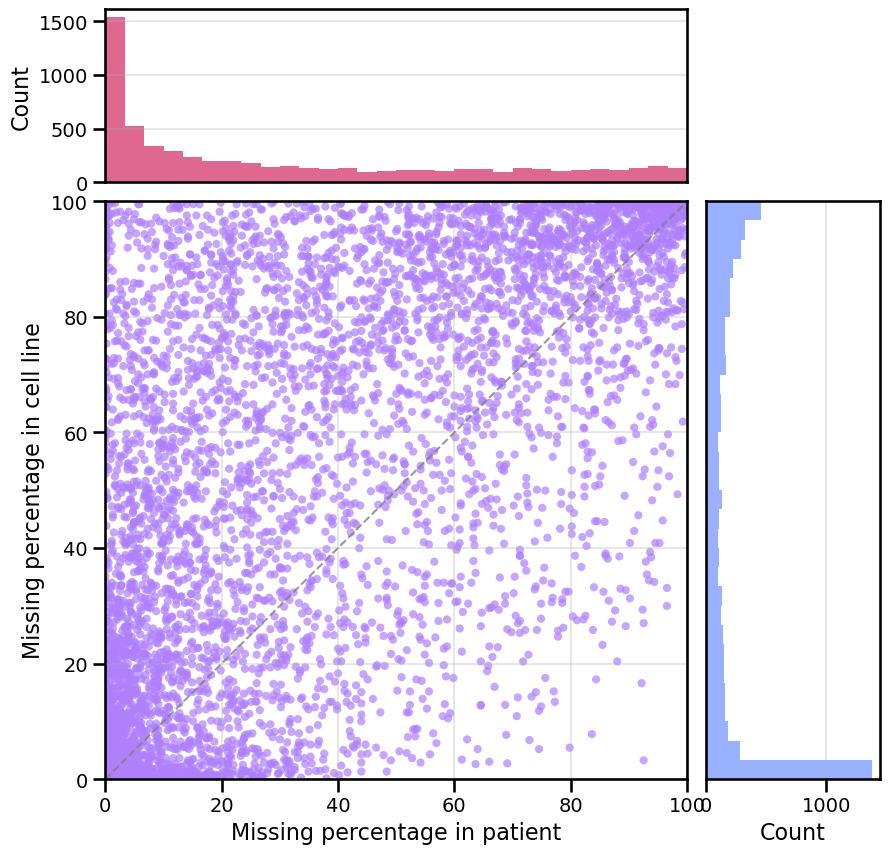

In [29]:
plot_protein_missingness_joint(adata_merged_tissue20)

In [30]:
def plot_tissue_type_histogram_per_source_faceted(
    adata,
    source_col="data_source",
    tissue_col="joint tissue type",
    figsize_per_panel=(5, 8),
    palette=palette_data_source_label_free,
):
    plt.rcParams.update({
        "font.size": 15,
        "axes.titlesize": 18,
        "axes.labelsize": 16,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
    })

    df = adata.obs[[source_col, tissue_col]].copy()

    sources = df[source_col].dropna().unique().tolist()
    tissue_order = (
        df[tissue_col]
        .value_counts()
        .index
        .tolist()
    )

    # Precompute counts and shared x limit
    counts_per_source = {}
    max_count = 0

    for src in sources:
        counts = (
            df.loc[df[source_col] == src, tissue_col]
            .value_counts()
            .reindex(tissue_order, fill_value=0)
        )
        counts_per_source[src] = counts
        max_count = max(max_count, counts.max())

    n = len(sources)
    fig, axes = plt.subplots(
        1, n,
        figsize=(figsize_per_panel[0] * n, figsize_per_panel[1]),
        sharey=True
    )
    if n == 1:
        axes = [axes]

    for ax, src in zip(axes, sources):
        counts = counts_per_source[src]

        ax.barh(
            counts.index,
            counts.values,
            color=palette[src],
            height=0.85,
        )
        ax.set_title(str(src))
        ax.set_xlabel("Number of samples")
        ax.set_xlim(0, max_count)
        ax.grid(True, axis="x", alpha=0.3)
        ax.invert_yaxis()

    axes[0].set_ylabel(tissue_col)
    fig.suptitle("Tissue type distribution per data source", y=1.02)
    plt.tight_layout()
    plt.show()

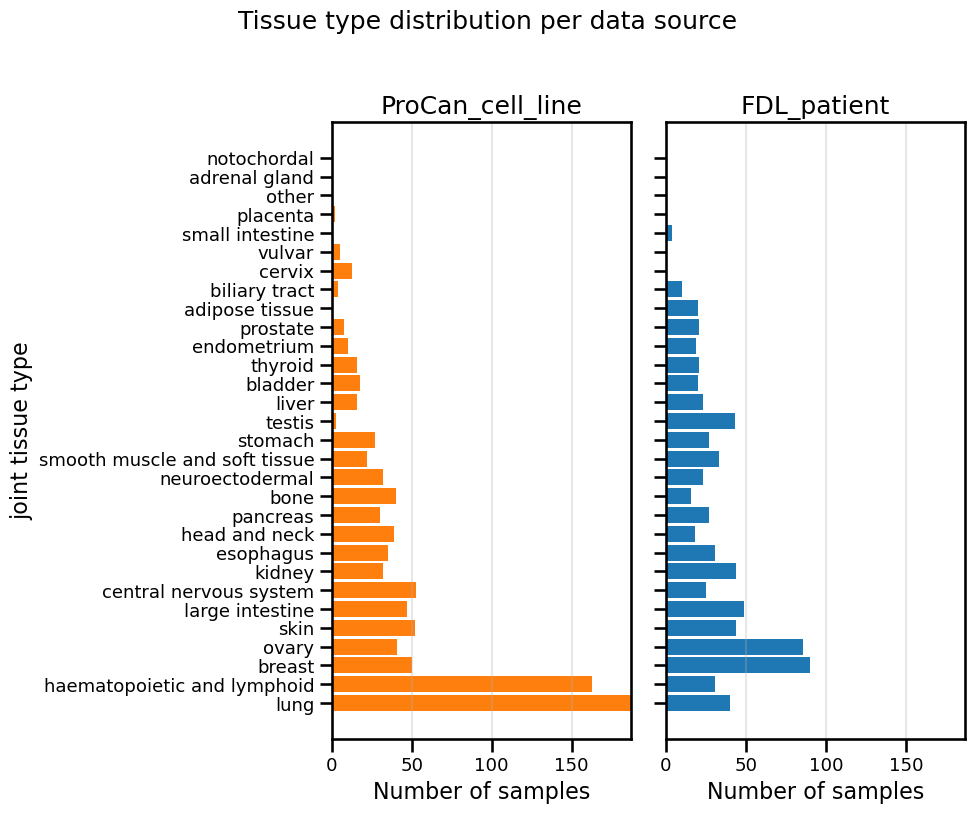

In [21]:
plot_tissue_type_histogram_per_source_faceted(adata_merged)

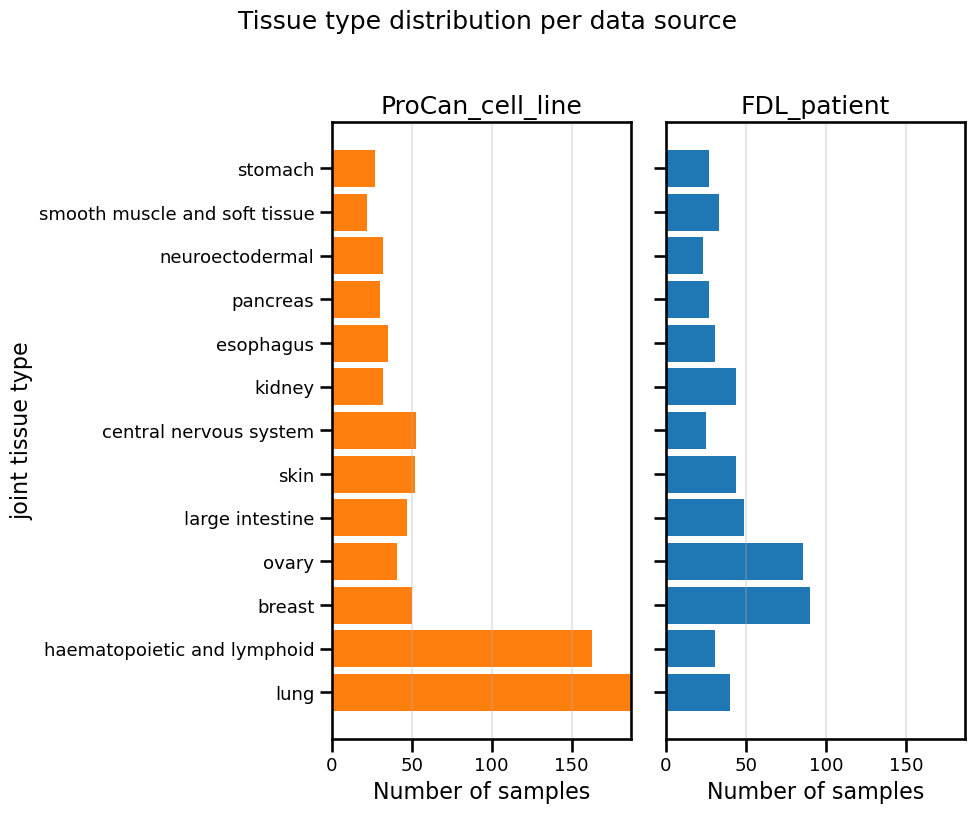

In [31]:
plot_tissue_type_histogram_per_source_faceted(adata_merged_tissue20)

In [16]:
## Filter proteins by missing percentage

def filter_proteins_by_detection_per_source(
    adata,
    source_col="data_source",
    detected_layer="detected",
    min_detected_fraction=0.20,
):
    """
    Filter proteins by requiring a minimum detection fraction in each source.

    Parameters
    ----------
    adata : AnnData
        AnnData object.
    source_col : str
        Column in adata.obs defining the source groups.
    detected_layer : str
        Layer containing boolean detection values
        (True = detected, False = missing).
    min_detected_fraction : float
        Minimum fraction of samples in each source in which a protein
        must be detected to be kept.
        Example: 0.20 means 20%.

    Returns
    -------
    AnnData
        Filtered AnnData object.
    """

    detected = adata.layers[detected_layer]
    sources = adata.obs[source_col]

    keep_mask = np.ones(adata.n_vars, dtype=bool)

    for source in sources.unique():
        source_mask = (sources == source).values

        if sparse.issparse(detected):
            det_source = detected[source_mask, :].toarray().astype(bool)
        else:
            det_source = np.asarray(detected[source_mask, :]).astype(bool)

        detected_fraction = det_source.mean(axis=0)
        keep_mask &= detected_fraction >= min_detected_fraction

    return adata[:, keep_mask].copy()

adata_filtered = filter_proteins_by_detection_per_source(
    adata_merged,
    source_col="data_source",
    detected_layer="detected",
    min_detected_fraction=0.20,
)

adata_filtered

AnnData object with n_obs × n_vars = 1715 × 4362
    obs: 'index', 'Cancer type', 'Cancer subtype', 'Tissue type', 'data_source', 'joint tissue type', 'joint Cancer type', 'joint Cancer subtype', 'matching cancer type', 'matching cancer subtype'
    var: 'UniprotID', 'organism'
    layers: 'detected'

              batch       rho      zeta  n_samples
0       FDL_patient  2.207867  1.308931        766
1  ProCan_cell_line  2.536534  1.314267        949


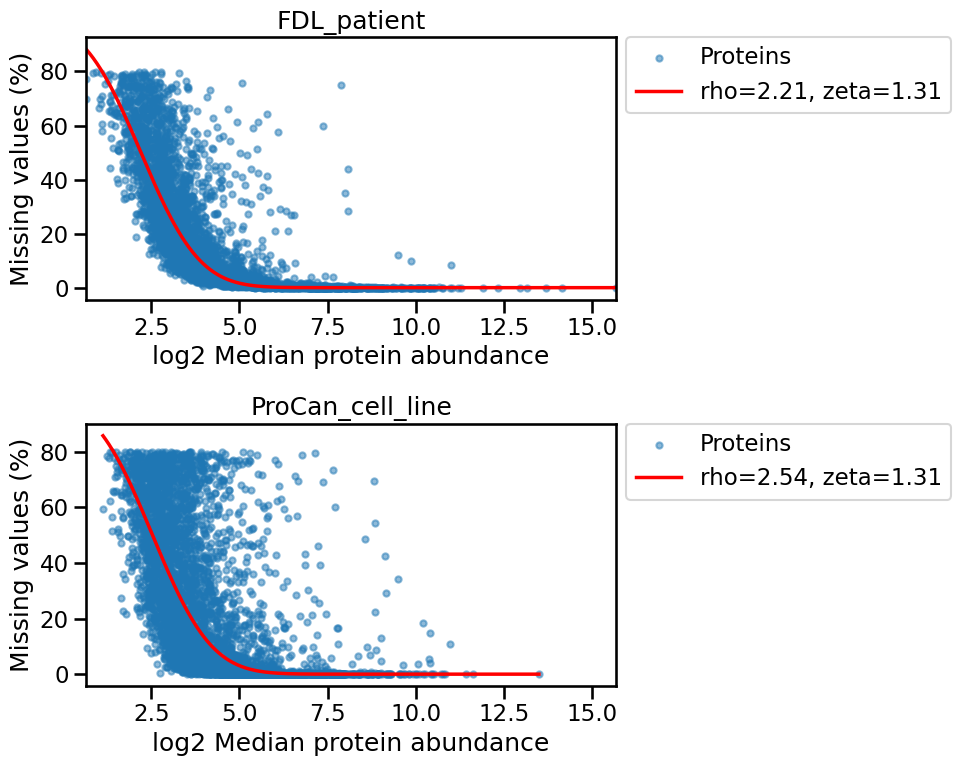

In [17]:
dropout_fit = estimate_dropout_params_by_batch_direct(
    adata_filtered,
    batch_key="data_source",
    detected_layer="detected",
)

print(dropout_fit["params_df"])

plot_median_missingness_by_data_source_directfit(dropout_fit)

         batch       rho      zeta  n_samples
0  FDL_patient  2.930999  1.121428        766


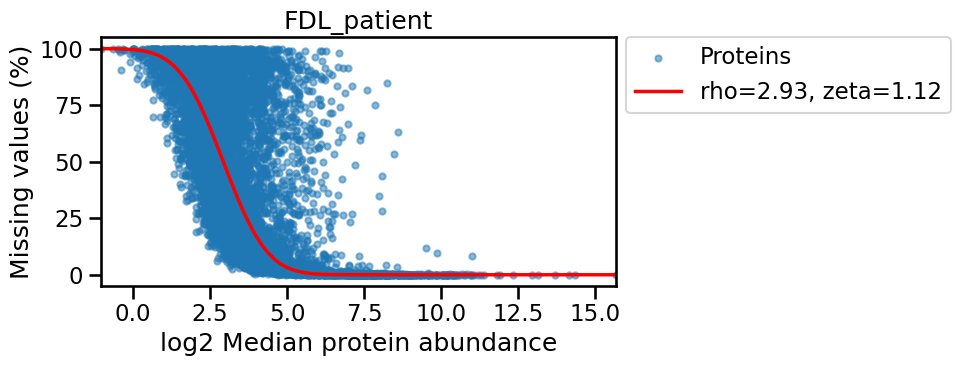

In [19]:
adata_FDL.layers["detected"] = ~np.isnan(adata_FDL.X)
dropout_fit = estimate_dropout_params_by_batch_direct(
    adata_FDL,
    batch_key="data_source",
    detected_layer="detected",
)

print(dropout_fit["params_df"])

plot_median_missingness_by_data_source_directfit(dropout_fit)

              batch       rho      zeta  n_samples
0  ProCan_cell_line  3.191524  1.169567        949


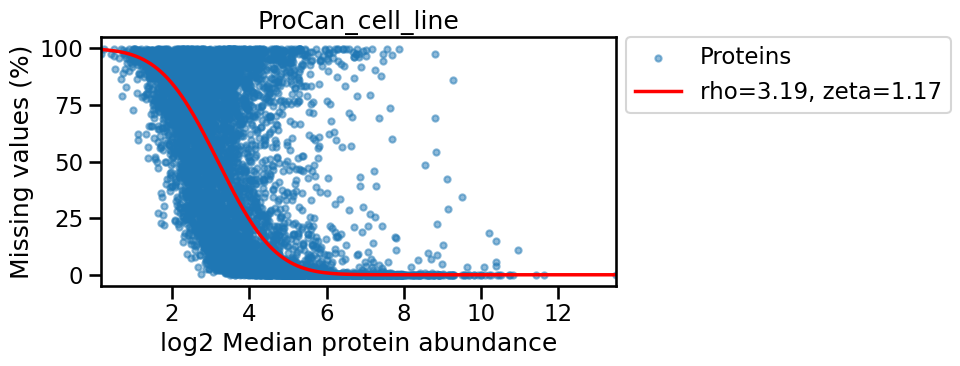

In [21]:
adata_Procan.layers["detected"] = ~np.isnan(adata_Procan.X)
dropout_fit = estimate_dropout_params_by_batch_direct(
    adata_Procan,
    batch_key="data_source",
    detected_layer="detected",
)

print(dropout_fit["params_df"])

plot_median_missingness_by_data_source_directfit(dropout_fit)

In [33]:
import numpy as np
from scipy import sparse

def filter_proteins_by_detection_any_source(
    adata,
    source_col="data_source",
    detected_layer="detected",
    min_detected_fraction=0.20,
):
    """
    Keep proteins detected in at least `min_detected_fraction`
    of samples in at least one source.

    Equivalent to removing proteins only if they are below the
    threshold in all sources.
    """

    detected = adata.layers[detected_layer]
    sources = adata.obs[source_col]

    # Keep if the protein passes threshold in at least one source
    keep_mask = np.zeros(adata.n_vars, dtype=bool)

    for source in sources.unique():
        source_mask = (sources == source).values

        if sparse.issparse(detected):
            det_source = detected[source_mask, :].toarray().astype(bool)
        else:
            det_source = np.asarray(detected[source_mask, :]).astype(bool)

        detected_fraction = det_source.mean(axis=0)
        keep_mask |= detected_fraction >= min_detected_fraction

    return adata[:, keep_mask].copy()

adata_filtered = filter_proteins_by_detection_any_source(
    adata_merged,
    source_col="data_source",
    detected_layer="detected",
    min_detected_fraction=0.2,
)
adata_filtered

AnnData object with n_obs × n_vars = 1715 × 5645
    obs: 'index', 'Cancer type', 'Cancer subtype', 'Tissue type', 'data_source', 'joint tissue type', 'joint Cancer type', 'joint Cancer subtype', 'matching cancer type', 'matching cancer subtype'
    var: 'UniprotID', 'organism'
    layers: 'detected'

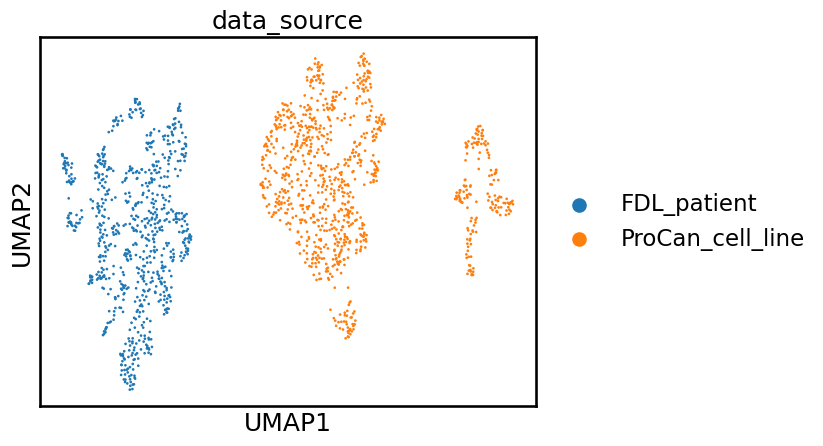

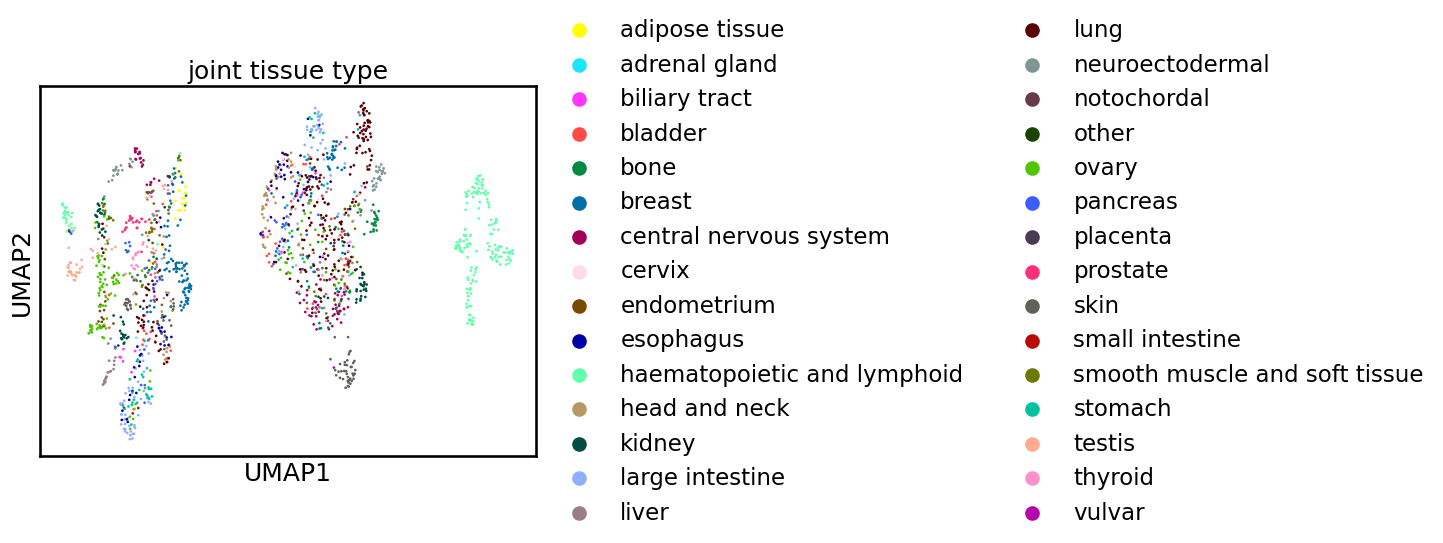

In [34]:
# quick umap of the adata
# Use the imputed layer as the working matrix
sc.pp.pca(adata_filtered, n_comps=50, mask_var=None)

# Build neighbor graph from the PCA representation computed above
sc.pp.neighbors(adata_filtered, n_neighbors=15, n_pcs=50, use_rep="X_pca")

# UMAP with your settings
sc.tl.umap(adata_filtered, min_dist=0.5)

# (Optional) quick plot
sc.pl.umap(adata_filtered, color="data_source", size=15)
sc.pl.umap(adata_filtered, color="joint tissue type", size=15)

              batch       rho      zeta  n_samples
0       FDL_patient  2.387703  1.270037        766
1  ProCan_cell_line  2.941504  1.226349        949


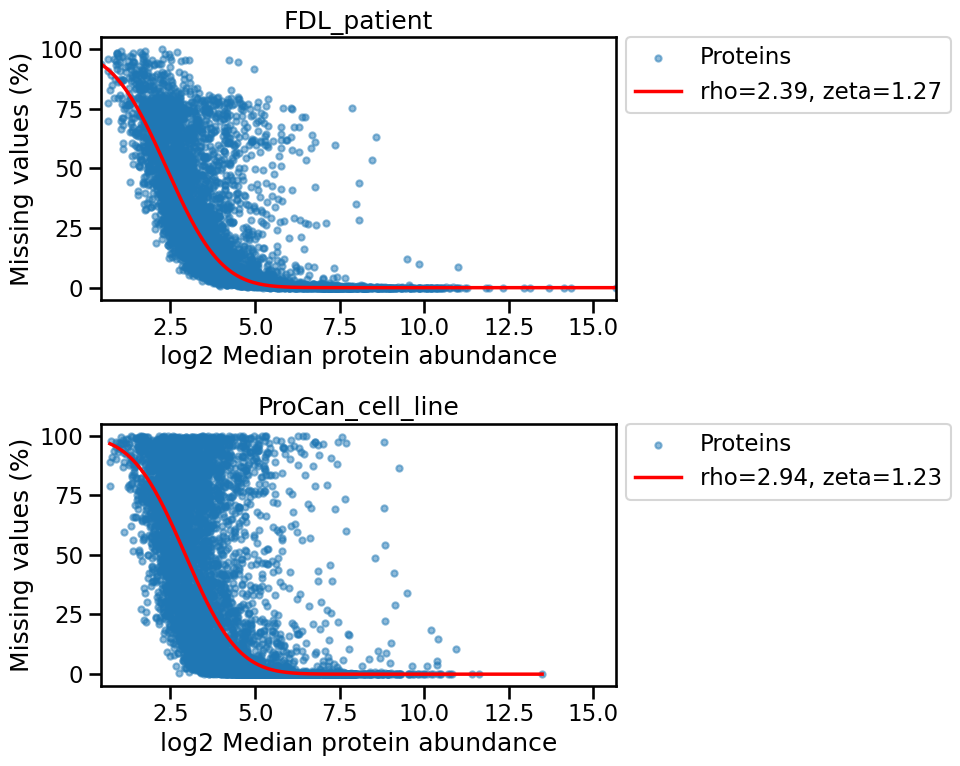

In [35]:
dropout_fit = estimate_dropout_params_by_batch_direct(
    adata_filtered,
    batch_key="data_source",
    detected_layer="detected",
)

print(dropout_fit["params_df"])

plot_median_missingness_by_data_source_directfit(dropout_fit)